# 🌦️ MeteoNet STM32 — 3 Capteurs · 6 Sorties
**Capteurs STM32 :** HTS221 (Température + Humidité) + LPS22HH (Pression)  
**Sorties :** 🌧️ Pluie · ☀️ Beau temps · ⛅ Nuageux · 🌫️ Brouillard · 💨 Vent fort · 🧊 Gel  
**Cible :** STM32N6 via STM32Cube.AI (TFLite INT8)

---
### 🗺️ Plan du notebook
1. Installation
2. Imports
3. Récupération des données Open-Meteo (10 ans)
4. Construction des features dérivées
5. Construction des 6 labels de sortie
6. Features · Split · Normalisation
7. Architecture du réseau multi-sorties
8. Entraînement
9. Courbes d'entraînement
10. Évaluation par classe
11. Fonction de prédiction — simulation STM32
12. Export des paramètres du scaler (pour main.c)
13. Export TFLite pour STM32Cube.AI
14. Code C complet pour STM32
15. Sauvegarde Google Drive

## 📦 1. Installation

In [1]:
!pip install openmeteo-requests requests-cache retry-requests tensorflow scikit-learn imbalanced-learn matplotlib seaborn pandas numpy

   ---------------------------------------- 0.0/235.4 kB ? eta -:--:--
   -------------------- ------------------- 122.9/235.4 kB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 235.4/235.4 kB 7.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   --------------------------------------- 294.9/294.9 kB 17.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📚 2. Imports

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score
)

import tensorflow as tf
from tensorflow import keras

print('✅ Imports OK')
print(f'   TensorFlow : {tf.__version__}')

✅ Imports OK
   TensorFlow : 2.20.0


## 🌍 3. Récupération des données Open-Meteo (10 ans)

In [7]:
# ============================================================
# ⚙️  PARAMÈTRES À MODIFIER
# ============================================================
LATITUDE    = 45.57      # Tullins — modifie selon ta ville
LONGITUDE   = 5.47
VILLE       = "Tullins"
DATE_DEBUT  = "2015-01-01"
DATE_FIN    = "2025-12-31"
SEUIL_PLUIE = 1.0        # mm  → jour de pluie
SEUIL_VENT  = 40.0       # km/h → vent fort
SEUIL_GEL   = 2.0        # °C Tmin → risque de gel
# ============================================================

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude"  : LATITUDE,
    "longitude" : LONGITUDE,
    "start_date": DATE_DEBUT,
    "end_date"  : DATE_FIN,
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "relative_humidity_2m_max",
        "relative_humidity_2m_min",
        "pressure_msl_mean",
        "precipitation_sum",
        "precipitation_hours",
        "windspeed_10m_max",
        "cloudcover_mean",
        "snowfall_sum",
        #"visibility_mean"
    ]
}

print(f"📡 Récupération des données pour {VILLE}...")
response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data["daily"])
df["date"] = pd.to_datetime(df["time"])
df = df.drop(columns=["time"])

print(f"✅ Données : {len(df)} jours ({DATE_DEBUT} → {DATE_FIN})")
df.head()

📡 Récupération des données pour Tullins...
✅ Données : 4018 jours (2015-01-01 → 2025-12-31)


,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,pressure_msl_mean,precipitation_sum,precipitation_hours,windspeed_10m_max,cloudcover_mean,snowfall_sum,date
0,1.5,-2.1,-0.9,90,72,1037.7,0.0,0.0,7.4,48,0.0,2015-01-01
1,4.6,-4.0,0.8,93,65,1037.6,0.0,0.0,6.2,78,0.0,2015-01-02
2,7.0,1.7,4.1,96,81,1032.8,4.3,10.0,6.6,99,0.0,2015-01-03
3,8.0,2.6,5.8,99,89,1032.8,5.8,12.0,10.0,87,0.0,2015-01-04
4,5.7,-2.0,1.5,97,68,1033.0,0.0,0.0,6.3,37,0.0,2015-01-05


## 🔧 4. Construction des 27 features
> ⚠️ **Toutes ces features sont calculables par la STM32 à partir de Temp, Hum et Pression uniquement.**

In [8]:
# ─── Dérivées immédiates ─────────────────────────────────────
df["humidity_mean"]  = (df["relative_humidity_2m_max"] + df["relative_humidity_2m_min"]) / 2
df["amplitude_temp"] = df["temperature_2m_max"] - df["temperature_2m_min"]
df["humidex"]        = df["temperature_2m_mean"] + 0.033 * df["humidity_mean"]

# ─── Lags J-1, J-2, J-3 ─────────────────────────────────────
for lag in [1, 2, 3]:
    df[f"temp_lag{lag}"]     = df["temperature_2m_mean"].shift(lag)
    df[f"humidity_lag{lag}"] = df["humidity_mean"].shift(lag)
    df[f"pressure_lag{lag}"] = df["pressure_msl_mean"].shift(lag)

# ─── Tendances (delta J vs J-1) ──────────────────────────────
df["delta_temp"]     = df["temperature_2m_mean"] - df["temp_lag1"]
df["delta_humidity"] = df["humidity_mean"]        - df["humidity_lag1"]
df["delta_pressure"] = df["pressure_msl_mean"]    - df["pressure_lag1"]

# ─── Moyennes glissantes 3 jours ─────────────────────────────
df["temp_3j"]     = df["temperature_2m_mean"].rolling(3).mean()
df["humidity_3j"] = df["humidity_mean"].rolling(3).mean()
df["pressure_3j"] = df["pressure_msl_mean"].rolling(3).mean()

# ─── Gradient de pression (indicateur météo très utile) ──────
df["gradient_pression_3j"] = df["pressure_msl_mean"] - df["pressure_3j"]

# ─── Encodage cyclique du mois ───────────────────────────────
df["mois"]     = df["date"].dt.month
df["sin_mois"] = np.sin(2 * np.pi * df["mois"] / 12)
df["cos_mois"] = np.cos(2 * np.pi * df["mois"] / 12)

df = df.dropna()
print(f"✅ Dataset prêt : {len(df)} jours")

✅ Dataset prêt : 4015 jours


## 🎯 5. Construction des 6 labels de sortie
> Ces labels sont construits à partir des colonnes Open-Meteo (vérité terrain pour l'entraînement).  
> La STM32 n'a besoin que de Temp+Hum+Pression pour prédire.

In [10]:
# ─── Nettoyage D'ABORD ──────────────────────────────────────
df = df.dropna()
print(f"✅ Dataset propre : {len(df)} jours")

# ─── 6 labels sans visibility_mean ──────────────────────────
df["pluie"]      = (df["precipitation_sum"]  > SEUIL_PLUIE).astype(int)

df["beau_temps"] = ((df["precipitation_sum"] < 0.1) &
                    (df["cloudcover_mean"]    < 40)).astype(int)

df["nuageux"]    = ((df["cloudcover_mean"]   >= 60) &
                    (df["precipitation_sum"]  < SEUIL_PLUIE)).astype(int)

# Brouillard estimé sans visibility_mean
df["brouillard"] = ((df["humidity_mean"]     > 92) &
                    (df["amplitude_temp"]     < 5)  &
                    (df["cloudcover_mean"]    > 70)).astype(int)

df["vent_fort"]  = (df["windspeed_10m_max"]  > SEUIL_VENT).astype(int)

df["gel"]        = (df["temperature_2m_min"] < SEUIL_GEL).astype(int)

LABELS    = ["pluie", "beau_temps", "nuageux", "brouillard", "vent_fort", "gel"]
LABELS_FR = ["🌧️ Pluie", "☀️ Beau temps", "⛅ Nuageux",
             "🌫️ Brouillard", "💨 Vent fort", "🧊 Gel"]

print("📊 Distribution des 6 classes :\n")
for lbl, fr in zip(LABELS, LABELS_FR):
    n   = int(df[lbl].sum())
    pct = n / len(df) * 100
    bar = '█' * min(int(pct / 2), 50)
    print(f"  {fr:<22} {n:>4} jours ({pct:4.1f}%)  {bar}")

✅ Dataset propre : 4015 jours
📊 Distribution des 6 classes :

  🌧️ Pluie               1421 jours (35.4%)  █████████████████
  ☀️ Beau temps          1044 jours (26.0%)  █████████████
  ⛅ Nuageux               850 jours (21.2%)  ██████████
  🌫️ Brouillard            44 jours ( 1.1%)  
  💨 Vent fort               1 jours ( 0.0%)  
  🧊 Gel                  1104 jours (27.5%)  █████████████


## ✂️ 6. Features (27) · Split · Normalisation

In [11]:
FEATURES = [
    # Valeurs brutes du jour J (mesurées par les 3 capteurs STM32)
    "temperature_2m_mean",       # 0  ← last_temp
    "temperature_2m_max",        # 1  ← last_temp + offset estimé
    "temperature_2m_min",        # 2  ← last_temp - offset estimé
    "humidity_mean",             # 3  ← last_rhum
    "relative_humidity_2m_max",  # 4
    "relative_humidity_2m_min",  # 5
    "pressure_msl_mean",         # 6  ← last_pres
    "amplitude_temp",            # 7  = Tmax - Tmin
    "humidex",                   # 8  = T + 0.033*H
    # Tendances J vs J-1
    "delta_temp",                # 9
    "delta_humidity",            # 10
    "delta_pressure",            # 11
    # Historique J-1
    "temp_lag1",                 # 12
    "humidity_lag1",             # 13
    "pressure_lag1",             # 14
    # Historique J-2
    "temp_lag2",                 # 15
    "humidity_lag2",             # 16
    "pressure_lag2",             # 17
    # Historique J-3
    "temp_lag3",                 # 18
    "humidity_lag3",             # 19
    "pressure_lag3",             # 20
    # Moyennes glissantes 3j
    "temp_3j",                   # 21
    "humidity_3j",               # 22
    "pressure_3j",               # 23
    # Gradient de pression
    "gradient_pression_3j",      # 24
    # Saisonnalité
    "sin_mois",                  # 25
    "cos_mois",                  # 26
]

N_FEATURES = len(FEATURES)
N_OUTPUTS  = len(LABELS)
print(f"✅ Features : {N_FEATURES}  |  Sorties : {N_OUTPUTS}")

X = df[FEATURES].values.astype(np.float32)
Y = df[LABELS].values.astype(np.float32)

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

print(f"Train : {X_train.shape[0]} jours | Val : {X_val.shape[0]} jours")

✅ Features : 27  |  Sorties : 6
Train : 3212 jours | Val : 803 jours


## 🧠 7. Architecture du réseau multi-sorties

In [12]:
tf.random.set_seed(42)

inp = keras.Input(shape=(N_FEATURES,), name="capteurs")

x = keras.layers.Dense(64, activation="relu")(inp)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.25)(x)

x = keras.layers.Dense(32, activation="relu")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.2)(x)

x = keras.layers.Dense(16, activation="relu")(x)

# 6 neurones sigmoid indépendants = 6 probabilités 0→1
out = keras.layers.Dense(N_OUTPUTS, activation="sigmoid", name="sorties")(x)

model = keras.Model(inputs=inp, outputs=out, name="MeteoNet_STM32")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()
print(f"\n📌 Entrée  : {N_FEATURES} features")
print(f"📌 Sortie  : {N_OUTPUTS} classes")
print(f"📌 Poids   : {model.count_params()} paramètres")

Model: "MeteoNet_STM32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capteurs (InputLayer)           │ (None, 27)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sorties (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,886 (19.09 KB)

 Trainable params: 4,694 (18.34 KB)

 Non-trainable params: 192 (768.00 B)


📌 Entrée  : 27 features
📌 Sortie  : 6 classes
📌 Poids   : 4886 paramètres


## 🏋️ 8. Entraînement

In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=20,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=8, min_lr=1e-6, verbose=1
    )
]

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3232 - loss: 0.5519 - val_accuracy: 0.4944 - val_loss: 0.5082 - learning_rate: 5.0000e-04
Epoch 2/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4290 - loss: 0.4122 - val_accuracy: 0.5479 - val_loss: 0.3665 - learning_rate: 5.0000e-04
Epoch 3/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4823 - loss: 0.3403 - val_accuracy: 0.5492 - val_loss: 0.2989 - learning_rate: 5.0000e-04
Epoch 4/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4975 - loss: 0.3066 - val_accuracy: 0.5666 - val_loss: 0.2681 - learning_rate: 5.0000e-04
Epoch 5/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5184 - loss: 0.2854 - val_accuracy: 0.5666 - val_loss: 0.2529 - learning_rate: 5.0000e-04
Epoch 6/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5174 - loss: 0.2712 - val_accuracy: 0.5616 - val_loss: 0.2431 - learning_rate: 5.0000e-04
Epoch 7/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc

## 📈 9. Courbes d'entraînement

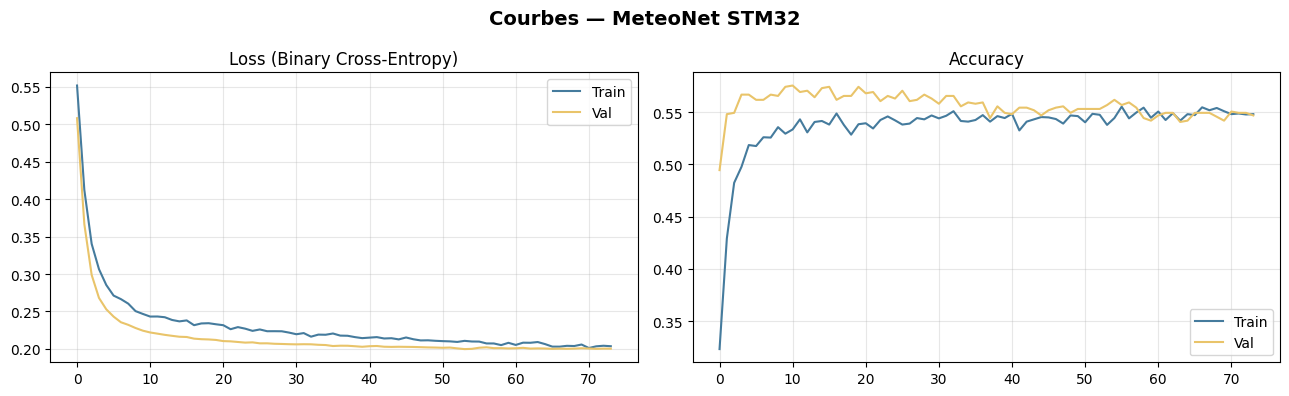

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history["loss"],     label="Train", color="#457b9d")
axes[0].plot(history.history["val_loss"], label="Val",   color="#e9c46a")
axes[0].set_title("Loss (Binary Cross-Entropy)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["accuracy"],     label="Train", color="#457b9d")
axes[1].plot(history.history["val_accuracy"], label="Val",   color="#e9c46a")
axes[1].set_title("Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Courbes — MeteoNet STM32", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 📊 10. Évaluation par classe

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
📊 Performance par classe :

Classe                    AUC   Préc.   Recall     F1
-------------------------------------------------------
  🌧️ Pluie                0.914   0.775    0.767  0.771
  ☀️ Beau temps           0.903   0.713    0.667  0.689
  ⛅ Nuageux               0.770   0.650    0.241  0.351
  🌫️ Brouillard           0.988   0.000    0.000  0.000
  💨 Vent fort             0.155   0.000    0.000  0.000
  🧊 Gel                   0.999   0.970    0.970  0.970


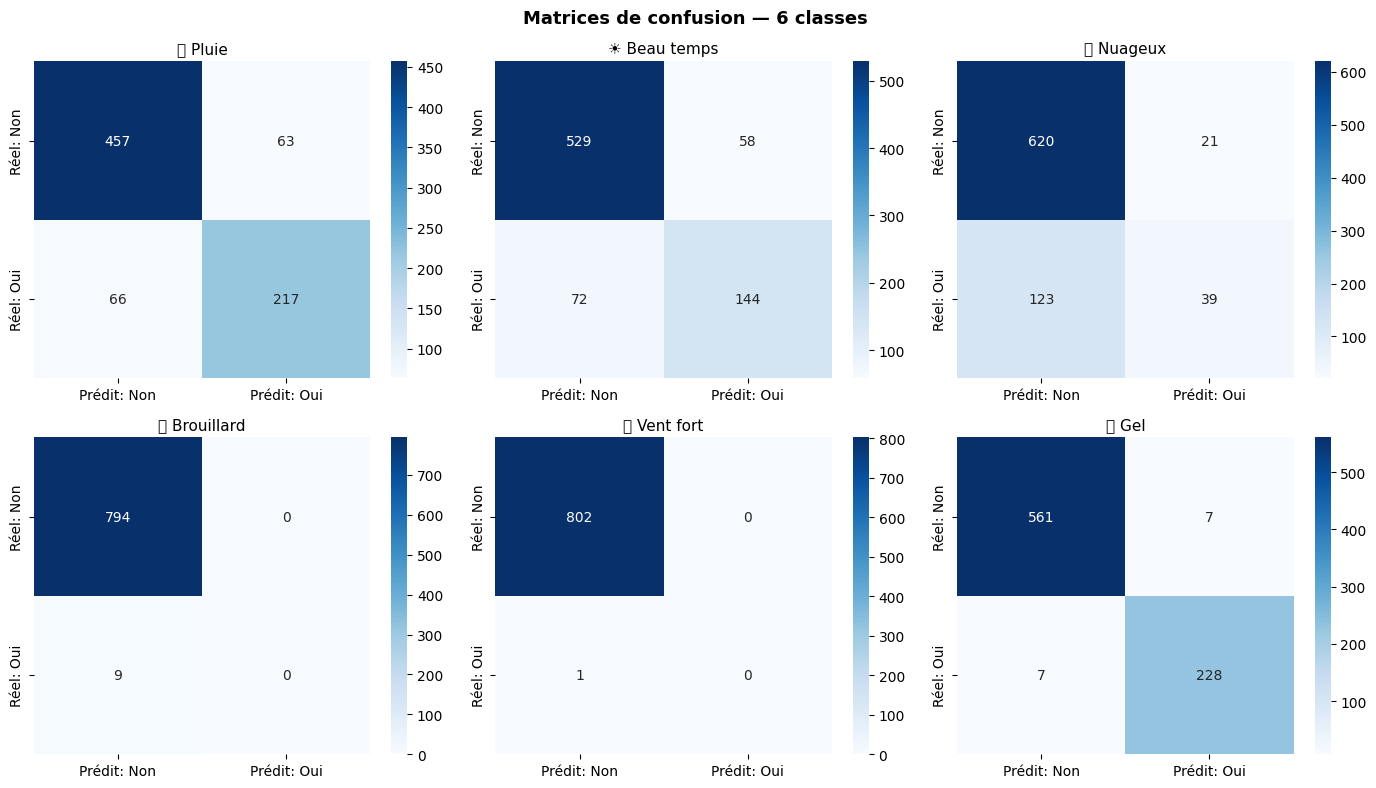

In [15]:
Y_proba = model.predict(X_val)

print("📊 Performance par classe :\n")
print(f"{'Classe':<22} {'AUC':>6} {'Préc.':>7} {'Recall':>8} {'F1':>6}")
print("-" * 55)

for i, (lbl, fr) in enumerate(zip(LABELS, LABELS_FR)):
    y_true = Y_val[:, i]
    y_prob = Y_proba[:, i]
    y_pred = (y_prob >= 0.5).astype(int)
    if y_true.sum() > 0:
        auc  = roc_auc_score(y_true, y_prob)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true,    y_pred, zero_division=0)
        f1   = f1_score(y_true,        y_pred, zero_division=0)
        print(f"  {fr:<22} {auc:>6.3f} {prec:>7.3f} {rec:>8.3f} {f1:>6.3f}")
    else:
        print(f"  {fr:<22}  (données insuffisantes)")

# Matrice de confusion pour la pluie
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, (lbl, fr) in enumerate(zip(LABELS, LABELS_FR)):
    ax = axes[i // 3][i % 3]
    y_true = Y_val[:, i]
    y_pred = (Y_proba[:, i] >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Prédit: Non', 'Prédit: Oui'],
                yticklabels=['Réel: Non',   'Réel: Oui'])
    ax.set_title(fr, fontsize=11)

plt.suptitle('Matrices de confusion — 6 classes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔮 11. Simulation de prédiction STM32

In [16]:
def predire_meteo(temp, hum, pression, mois=None, historique_3j=None):
    """
    Simule exactement ce que fera le code C STM32.
    temp     : température moyenne °C
    hum      : humidité relative %
    pression : pression hPa
    mois     : 1-12 (None = mois actuel)
    historique_3j : [(T,H,P), (T,H,P), (T,H,P)] pour J-1, J-2, J-3
    """
    import datetime
    if mois is None:
        mois = datetime.datetime.now().month
    if historique_3j is None:
        historique_3j = [(temp, hum, pression)] * 3

    t1, h1, p1 = historique_3j[0]
    t2, h2, p2 = historique_3j[1]
    t3, h3, p3 = historique_3j[2]

    temp_3j = (temp + t1 + t2) / 3
    hum_3j  = (hum  + h1 + h2) / 3
    pres_3j = (pression + p1 + p2) / 3

    raw = np.array([[
        temp,          temp + 3,      temp - 3,
        hum,           min(100, hum+5), max(0, hum-5),
        pression,      6.0,           temp + 0.033*hum,
        temp - t1,     hum - h1,      pression - p1,
        t1, h1, p1,    t2, h2, p2,    t3, h3, p3,
        temp_3j, hum_3j, pres_3j,
        pression - pres_3j,
        np.sin(2 * np.pi * mois / 12),
        np.cos(2 * np.pi * mois / 12)
    ]], dtype=np.float32)

    probas = model.predict(scaler.transform(raw), verbose=0)[0]

    print(f"\n🌡️ T={temp}°C  💧 H={hum}%  🔵 P={pression}hPa  📅 Mois={mois}")
    print("━" * 45)
    print("  SORTIES DU RÉSEAU DE NEURONES :")
    print("━" * 45)
    for fr, p in zip(LABELS_FR, probas):
        bar  = '█' * int(p * 25)
        flag = '  ◀ OUI' if p >= 0.5 else ''
        print(f"  {fr:<22} {p*100:5.1f}%  {bar}{flag}")
    print("━" * 45)

# ── Tests ───────────────────────────────────────────────────
print("=== Test 1 : Jour pluvieux d'automne ===")
predire_meteo(temp=12.5, hum=88.0, pression=1003.0, mois=10)

print("\n=== Test 2 : Beau jour d'été ===")
predire_meteo(temp=28.0, hum=42.0, pression=1018.0, mois=7)

print("\n=== Test 3 : Nuit de gel en hiver ===")
predire_meteo(temp=1.0, hum=90.0, pression=1024.0, mois=1)

print("\n=== Test 4 : Avec historique de 3 jours ===")
predire_meteo(
    temp=15.0, hum=82.0, pression=1006.0, mois=4,
    historique_3j=[(17.0, 78.0, 1010.0),
                   (19.0, 72.0, 1013.0),
                   (20.0, 68.0, 1015.0)]
)

=== Test 1 : Jour pluvieux d'automne ===

🌡️ T=12.5°C  💧 H=88.0%  🔵 P=1003.0hPa  📅 Mois=10
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SORTIES DU RÉSEAU DE NEURONES :
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🌧️ Pluie                94.5%  ███████████████████████  ◀ OUI
  ☀️ Beau temps            0.1%  
  ⛅ Nuageux                3.3%  
  🌫️ Brouillard            0.7%  
  💨 Vent fort              0.0%  
  🧊 Gel                    0.0%  
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

=== Test 2 : Beau jour d'été ===

🌡️ T=28.0°C  💧 H=42.0%  🔵 P=1018.0hPa  📅 Mois=7
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SORTIES DU RÉSEAU DE NEURONES :
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🌧️ Pluie                 3.0%  
  ☀️ Beau temps           38.9%  █████████
  ⛅ Nuageux               24.3%  ██████
  🌫️ Brouillard            0.0%  
  💨 Vent fort              0.0%  
  🧊 Gel                    0.0%  
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

=== Test 3 : Nuit de gel en 

## 💻 12. Export des paramètres du Scaler
> Copiez ces valeurs dans votre `main.c` STM32

In [17]:
print("/* ============================================================")
print(" * PARAMÈTRES DU SCALER — coller dans main.c STM32")
print(" * Généré automatiquement par le notebook")
print(" * ============================================================ */")
print(f"\n#define N_FEATURES {N_FEATURES}")
print(f"#define N_OUTPUTS  {N_OUTPUTS}")
print()

mean_vals = ", ".join([f"{v:.6f}f" for v in scaler.mean_])
std_vals  = ", ".join([f"{v:.6f}f" for v in scaler.scale_])

print("static const float SCALER_MEAN[N_FEATURES] = {")
print(f"    {mean_vals}")
print("};")
print()
print("static const float SCALER_STD[N_FEATURES] = {")
print(f"    {std_vals}")
print("};")
print()
print("/* Sorties du réseau (out_data[i]) :")
for i, (lbl, fr) in enumerate(zip(LABELS, LABELS_FR)):
    print(f" *   out_data[{i}] = {fr} ({lbl})")
print(" */")

/* ============================================================
 * PARAMÈTRES DU SCALER — coller dans main.c STM32
 * Généré automatiquement par le notebook
 * ============================================================ */

#define N_FEATURES 27
#define N_OUTPUTS  6

static const float SCALER_MEAN[N_FEATURES] = {
    12.027117f, 17.021980f, 7.241065f, 73.637453f, 92.273973f, 55.000934f, 1018.042248f, 9.780915f, 14.457153f, -0.004328f, -0.013076f, 0.041843f, 12.031445f, 73.650529f, 1018.000405f, 12.013169f, 73.739103f, 1018.009714f, 12.043213f, 73.646326f, 1018.064477f, 12.023910f, 73.675695f, 1018.017455f, 0.024792f, -0.012102f, -0.005701f
};

static const float SCALER_STD[N_FEATURES] = {
    7.570319f, 8.401702f, 6.832124f, 10.221421f, 7.130148f, 15.282062f, 7.402988f, 3.505532f, 7.381430f, 1.956011f, 7.379057f, 4.238561f, 7.556106f, 10.191839f, 7.397784f, 7.574693f, 10.197281f, 7.404213f, 7.596477f, 10.122340f, 7.379851f, 7.448834f, 9.096466f, 6.777525f, 3.416645f, 0.704853f, 0.7092

## 🚀 13. Export TFLite pour STM32Cube.AI

In [18]:
# ── Keras ────────────────────────────────────────────────────
model.save("meteonet_stm32.keras")
print("✅ Keras : meteonet_stm32.keras")

# ── TFLite standard ──────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_std = converter.convert()
with open("meteonet_stm32.tflite", "wb") as f:
    f.write(tflite_std)
print(f"✅ TFLite standard   : {len(tflite_std)/1024:.1f} Ko")

# ── TFLite INT8 (pour STM32Cube.AI) ─────────────────────────
def representative_dataset():
    for i in range(0, min(200, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
converter_q.representative_dataset = representative_dataset
converter_q.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_q.inference_input_type  = tf.float32
converter_q.inference_output_type = tf.float32

tflite_quant = converter_q.convert()
with open("meteonet_stm32_quant.tflite", "wb") as f:
    f.write(tflite_quant)
print(f"✅ TFLite INT8       : {len(tflite_quant)/1024:.1f} Ko")
print(f"   Réduction         : {(1 - len(tflite_quant)/len(tflite_std))*100:.0f}%")

# ── Scaler ───────────────────────────────────────────────────
with open("meteonet_scaler.pkl", "wb") as f:
    pickle.dump({"scaler": scaler, "features": FEATURES,
                 "labels": LABELS, "labels_fr": LABELS_FR}, f)
print("✅ Scaler : meteonet_scaler.pkl")

print()
print("📌 → Charger meteonet_stm32_quant.tflite dans STM32Cube.AI")
print("📌 → Le nom du modèle C sera 'meteo' (comme avant)")

✅ Keras : meteonet_stm32.keras
INFO:tensorflow:Assets written to: C:\Temp\tmpaxmd2_pe\assets


INFO:tensorflow:Assets written to: C:\Temp\tmpaxmd2_pe\assets


Saved artifact at 'C:\Temp\tmpaxmd2_pe'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 27), dtype=tf.float32, name='capteurs')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2343096693776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096692816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096694928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096693968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096693200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096695888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096696080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096696656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096694736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096696272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096695120: TensorSpec(shape=(), dtype=tf

INFO:tensorflow:Assets written to: C:\Temp\tmpt3akpdye\assets


Saved artifact at 'C:\Temp\tmpt3akpdye'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 27), dtype=tf.float32, name='capteurs')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2343096693776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096692816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096694928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096693968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096693200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096695888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096696080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096696656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096694736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096696272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343096695120: TensorSpec(shape=(), dtype=tf

## 💻 14. Code C complet pour STM32 — main.c
> Remplacez `ai_run()` dans votre `main.c` par ce code après régénération STM32Cube.AI

In [ ]:
print("""
/* ============================================================
 * main.c — MeteoNet STM32 — 27 features, 6 sorties
 * ============================================================
 * ÉTAPES APRÈS RÉGÉNÉRATION STM32Cube.AI :
 *   1. Coller SCALER_MEAN et SCALER_STD (étape 12 du notebook)
 *   2. Modifier in_data[AI_METEO_IN_1_SIZE] -> taille 27
 *   3. Modifier out_data[AI_METEO_OUT_1_SIZE] -> taille 6
 * ============================================================ */

#include <math.h>   /* sinf, cosf, fminf, fmaxf */
#include <time.h>   /* pour le mois courant (optionnel) */

#define N_FEATURES 27
#define N_OUTPUTS   6

/* === COLLER ICI les valeurs générées à l'étape 12 === */
static const float SCALER_MEAN[N_FEATURES] = {
    /* ... valeurs du notebook ... */
};
static const float SCALER_STD[N_FEATURES] = {
    /* ... valeurs du notebook ... */
};
/* ==================================================== */

static const char* LABELS[N_OUTPUTS] = {
    "Pluie", "Beau temps", "Nuageux",
    "Brouillard", "Vent fort", "Gel"
};

/* Historique des 3 derniers jours */
static float hist_temp[3] = {20.f, 20.f, 20.f};
static float hist_hum[3]  = {70.f, 70.f, 70.f};
static float hist_pres[3] = {1013.f, 1013.f, 1013.f};
static uint8_t hist_init  = 0;

static void ai_run(uint8_t mois)
{
    float t = last_temp, h = last_rhum, p = last_pres;

    /* Initialisation de l'historique au premier appel */
    if (!hist_init) {
        for (int i = 0; i < 3; i++) {
            hist_temp[i] = t;
            hist_hum[i]  = h;
            hist_pres[i] = p;
        }
        hist_init = 1;
    }

    float t1 = hist_temp[0], h1 = hist_hum[0], p1 = hist_pres[0]; /* J-1 */
    float t2 = hist_temp[1], h2 = hist_hum[1], p2 = hist_pres[1]; /* J-2 */
    float t3 = hist_temp[2], h3 = hist_hum[2], p3 = hist_pres[2]; /* J-3 */

    float temp_3j = (t + t1 + t2) / 3.0f;
    float hum_3j  = (h + h1 + h2) / 3.0f;
    float pres_3j = (p + p1 + p2) / 3.0f;
    float pi      = 3.14159265f;

    /* Vecteur brut de 27 features */
    float raw[N_FEATURES] = {
        t,           t + 3.0f,       t - 3.0f,        /* 0-2  temp moy/max/min  */
        h,           fminf(100,h+5), fmaxf(0,h-5),    /* 3-5  hum  moy/max/min  */
        p,           6.0f,           t + 0.033f*h,    /* 6-8  pres, amp, humidex*/
        t - t1,      h - h1,         p - p1,          /* 9-11 deltas            */
        t1, h1, p1,                                   /* 12-14 lag J-1          */
        t2, h2, p2,                                   /* 15-17 lag J-2          */
        t3, h3, p3,                                   /* 18-20 lag J-3          */
        temp_3j, hum_3j, pres_3j,                     /* 21-23 moyennes 3j      */
        p - pres_3j,                                  /* 24   gradient pression */
        sinf(2.0f * pi * mois / 12.0f),               /* 25   sin_mois          */
        cosf(2.0f * pi * mois / 12.0f)                /* 26   cos_mois          */
    };

    /* Normalisation Z-score */
    for (int i = 0; i < N_FEATURES; i++)
        in_data[i] = (raw[i] - SCALER_MEAN[i]) / SCALER_STD[i];

    /* Inférence */
    ai_i32 n = ai_meteo_run(ai_meteo, ai_input, ai_output);
    if (n <= 0) {
        HAL_UART_Transmit(&hcom_uart[COM1],
            (uint8_t*)"[AI] ERREUR\\r\\n", 13, 1000);
        return;
    }

    /* Affichage de toutes les sorties */
    char buf[64];
    HAL_UART_Transmit(&hcom_uart[COM1],
        (uint8_t*)"--- METEO AI ---\\r\\n", 18, 1000);

    for (int i = 0; i < N_OUTPUTS; i++) {
        float pct = out_data[i] * 100.0f;
        snprintf(buf, sizeof(buf), "  %-12s: %5.1f%%%s\\r\\n",
                 LABELS[i], pct, (pct >= 50.0f) ? " <<<" : "");
        HAL_UART_Transmit(&hcom_uart[COM1], (uint8_t*)buf, strlen(buf), 1000);
    }

    /* LEDs : LED2 = pluie, LED1 = beau temps */
    if      (out_data[0] >= 0.5f) { BSP_LED_On(LED2); BSP_LED_Off(LED1); }
    else if (out_data[1] >= 0.5f) { BSP_LED_On(LED1); BSP_LED_Off(LED2); }
    else                           { BSP_LED_Off(LED1); BSP_LED_Off(LED2); }

    /* Décalage de l'historique (appel toutes les 24h idéalement) */
    hist_temp[2] = hist_temp[1]; hist_hum[2] = hist_hum[1]; hist_pres[2] = hist_pres[1];
    hist_temp[1] = hist_temp[0]; hist_hum[1] = hist_hum[0]; hist_pres[1] = hist_pres[0];
    hist_temp[0] = t;            hist_hum[0]  = h;           hist_pres[0] = p;
}

/* Dans main(), appel toutes les 2 secondes : */
/*   ai_run(mois_courant);  // ex: ai_run(4) pour avril */
""")

## ☁️ 15. Sauvegarde Google Drive

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
fichiers = [
    "meteonet_stm32.tflite",
    "meteonet_stm32_quant.tflite",
    "meteonet_stm32.keras",
    "meteonet_scaler.pkl"
]
for f in fichiers:
    shutil.copy(f, f"/content/drive/MyDrive/{f}")
    print(f"✅ {f} → Google Drive")

print("\n📌 Charger meteonet_stm32_quant.tflite dans STM32Cube.AI")
print("📌 Copier les SCALER_MEAN et SCALER_STD (étape 12) dans main.c")

ModuleNotFoundError: No module named 'google.colab'